In [1]:
pip install lime

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
    --------------------------------------- 0.3/11.9 MB ? eta -:--:--
    --------------------------------------- 0.3/11.9 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.9 MB 479.2 kB/s eta 0:00:24
   - -------------------------------------- 0.5/11.9 MB 479.2 kB/s eta 0:00:24
   -- ------------------------------------- 0.8/11.9 MB 621.2 kB/s eta 0:00:18
   --- ------------------------------------ 1.0/11.9 MB 689.2 kB/s eta 0:00:16
   --- --


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install lime scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Model Accuracy: 0.96

Predicted Class:
benign

Prediction Probabilities:
[0.03 0.97]

Top Features Influencing Prediction:

516.45 < worst area <= 686.60            0.0754
84.25 < worst perimeter <= 97.67         0.0435
13.05 < worst radius <= 14.97            0.0396
0.06 < mean concavity <= 0.13            -0.0223
24.72 < area error <= 43.73              0.0195


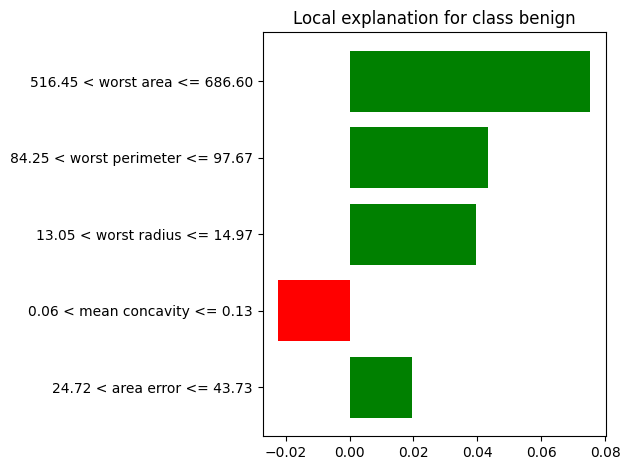

In [5]:


import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from lime.lime_tabular import LimeTabularExplainer

# ---------------------------------------------------
# Load Dataset
# ---------------------------------------------------

data = load_breast_cancer()

X = data.data
y = data.target

feature_names = data.feature_names
class_names = data.target_names

# ---------------------------------------------------
# Train-Test Split
# ---------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ---------------------------------------------------
# Train Random Forest
# ---------------------------------------------------

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

# ---------------------------------------------------
# Model Accuracy
# ---------------------------------------------------

accuracy = model.score(X_test, y_test)

print(f"Model Accuracy: {accuracy:.2f}")

# ---------------------------------------------------
# Create LIME Explainer
# ---------------------------------------------------

explainer = LimeTabularExplainer(
    training_data=X_train,
    feature_names=feature_names,
    class_names=class_names,
    mode="classification"
)

# ---------------------------------------------------
# Pick a Test Record
# ---------------------------------------------------

sample_index = 0

sample = X_test[sample_index]

# ---------------------------------------------------
# Prediction
# ---------------------------------------------------

prediction = model.predict([sample])[0]

prediction_probability = model.predict_proba([sample])[0]

print("\nPredicted Class:")
print(class_names[prediction])

print("\nPrediction Probabilities:")
print(prediction_probability)

# ---------------------------------------------------
# Generate LIME Explanation
# ---------------------------------------------------

explanation = explainer.explain_instance(
    data_row=sample,
    predict_fn=model.predict_proba,
    num_features=5
)

# ---------------------------------------------------
# Display Explanation as Text
# ---------------------------------------------------

print("\nTop Features Influencing Prediction:\n")

for feature, weight in explanation.as_list():
    print(f"{feature:40} {weight:.4f}")

# ---------------------------------------------------
# Display Explanation as Chart
# ---------------------------------------------------

fig = explanation.as_pyplot_figure()

plt.tight_layout()
plt.show()